In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Basic_functions as bf

from sklearn.preprocessing import StandardScaler, RobustScaler
import lightgbm as lgbm
from lightgbm import early_stopping

In [2]:
chars = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "æ", "ø", "å", " "]
data, labels = bf.read_files("Speeches", chars)

In [12]:
words_used = np.genfromtxt("txt_files/word_counts.txt", delimiter=" ", dtype=str)

In [14]:
words = words_used[:, 0]
counts = words_used[:, 1].astype(int)

In [27]:
raw = open("Speeches/Zenia_Stampes_grundlovstale.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)
text = text.strip().lower().replace("\n", " ")
header_lines = header.splitlines()

In [22]:
#np.savetxt("words_by_speech.csv", words, delimiter=",", fmt="%s")
#np.savetxt("counts_by_speech.csv", counts, delimiter=",", fmt="%d")
with open("txt_files/words_by_speech.txt", "w", encoding="utf-8") as f:
    for i in range(len(words)):
        for j in range(len(words[i])):
            f.write(words[i][j])
            f.write(", ")
        f.write("\n")
with open("txt_files/counts_by_speech.txt", "w") as f:
    for i in range(len(counts)):
        for j in range(len(counts[i])):
            f.write(str(counts[i][j]))
            f.write(", ")
        f.write("\n")

In [20]:
data, labels = bf.read_files("Speeches", words[:13360])

In [31]:
data = np.array(data)
labels = np.array(labels)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
dates = np.array(labels[:, 0], dtype=float)
preach = np.array(labels[:, 1], dtype=int)
#data_scaled = data_scaled[dates > 2020]
#labels_scaled = dates[dates > 2020]
#labels_scaled = labels_scaled

In [35]:
labels_scaled = np.array(preach, dtype=int)

In [38]:
params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [39]:
train_data = data_scaled[:int(0.8*len(data_scaled))]
train_labels = labels_scaled[:int(0.8*len(labels_scaled))]
val_data = data_scaled[int(0.8*len(data_scaled)):int(0.95*len(data_scaled))]
val_labels = labels_scaled[int(0.8*len(labels_scaled)):int(0.95*len(labels_scaled))]
test_data = data_scaled[int(0.95*len(data_scaled)):]
test_labels = labels_scaled[int(0.95*len(labels_scaled)):]
lgb_train = lgbm.Dataset(train_data, label=train_labels)
lgb_val = lgbm.Dataset(val_data, label=val_labels, reference=lgb_train)
model = lgbm.train(params, lgb_train, valid_sets=[lgb_train, lgb_val], num_boost_round=1000, callbacks=[early_stopping(50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[749]	training's binary_logloss: 0.0276921	valid_1's binary_logloss: 0.16075


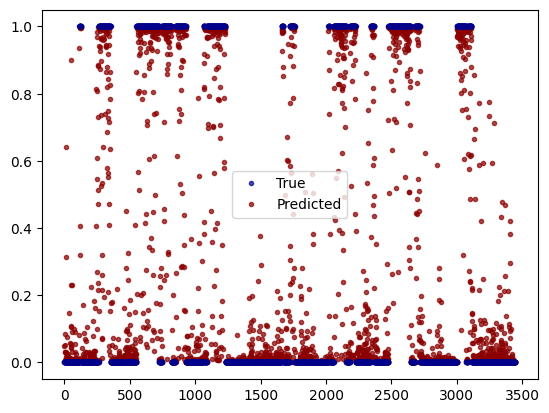

In [50]:
plt.plot(test_labels, '.', label="True", alpha=0.7, color="darkblue", zorder=3)
plt.plot(model.predict(test_data), '.', label="Predicted", alpha=0.7, color="darkred")
plt.legend()
plt.show()

In [40]:
idx = np.argsort(model.feature_importance(importance_type="gain"))[::-1]
print(words[:13360][idx][:20])

['gud' 'jesu' 'herren' 'herre' 'død' 'guds' 'r' 'a' 'evangeliet' 'jeg'
 'han' 'danmark' 'kirke' 'dansk' 'ti' 'kvinde' 'p' 'aa' 'de' 'arbejde']


In [41]:
np.savetxt("txt_files/words_ranked_preach.txt", words[:13360][idx], delimiter="\n", fmt="%s")

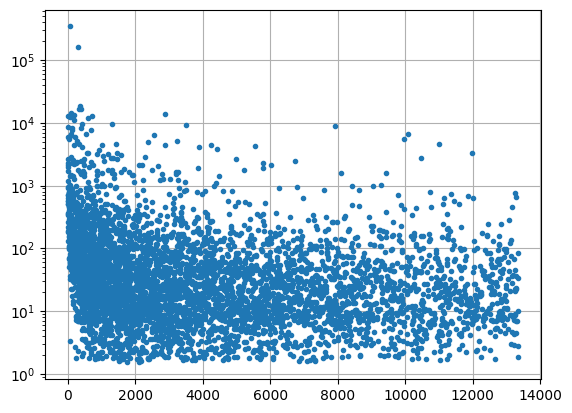

In [42]:
plt.plot(model.feature_importance(importance_type="gain"), ".")
plt.yscale("log")
plt.grid()

In [6]:
test_speech = open("test.txt", "r").read()
test_speech_data = bf.convert_to_data(test_speech, chars)

In [7]:
model.predict([test_speech_data])

array([23.64302537])

In [27]:
np.mean(labels)

np.float64(1993.833620919064)

In [13]:
model.predict(test_data)

array([ -43.45949295,  -55.31170448,  -41.86957323,  -61.60097825,
        -32.50387642,   15.8978201 ,   26.50305802,   10.3817101 ,
         23.54973952,  -75.1508267 ,   25.89405299,   24.26719992,
         19.27546165,   21.88278845,   18.91638827,   23.53752988,
         31.7233499 ,   15.75853587, -122.08753968,   23.71300754,
         18.44896129,   23.31839616,   16.0102125 ,   21.19210292,
          5.51567146,   21.60828215,   25.42972843,   25.01657786,
         26.29343679,   23.92454995,   26.18655454,   23.69506529,
         10.65264355,   24.38383314,   10.64566627,   23.69690549,
         23.34904098,   16.09072231,   22.8684581 ,   23.79729154,
         20.85383015,   24.04316806,   24.12764137,   23.89440954,
         16.31669968,   10.35891703,   20.33592943,   19.16334952,
         20.64140921,   24.11454124,   28.26948276,   25.23077268,
         26.1321853 ,   24.29464827,   17.40945138,   18.31327158,
          7.73357783,   16.13740252,   18.38265718,   15.15270

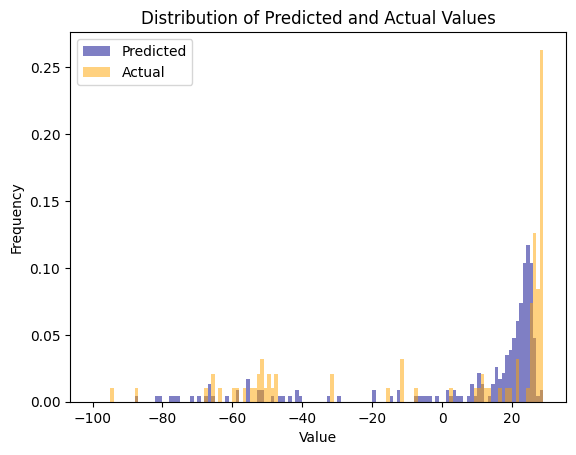

In [25]:
plt.hist(model.predict(test_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(test_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()

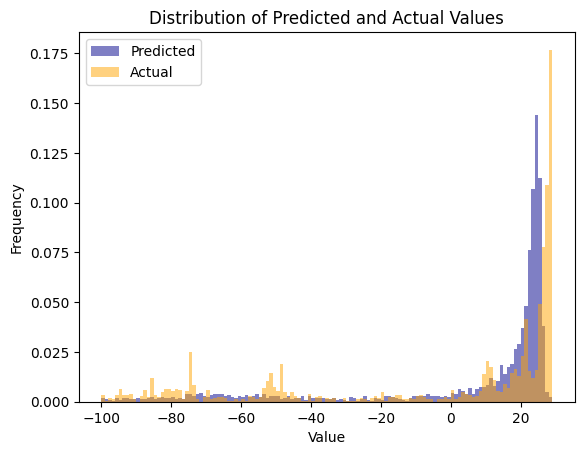

In [26]:
plt.hist(model.predict(train_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(train_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()